# Objective:
## Predict diabetes risk from patient diagnostic data using logistic regression, with a focus on interpretability (which factors matter, and by how much) and a threshold choice grounded in the real cost tradeoff of screening errors.

## Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore")


# Import and inspect data

In [2]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Check Class Imbalance

In [5]:
df['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

## That confirms it: 65.1% no diabetes / 34.9% diabetes — mild-to-moderate imbalance.
### What this means for this project:
    Not severe enough to require SMOTE or aggressive resampling
    But severe enough that accuracy alone is misleading — a dumb model that always predicts "no diabetes" would score ~65% accuracy while catching zero actual diabetics.
## We'll fix that later

# Handling Missing Values

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## But there are zeros in some columns which are technically impossible

In [7]:
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','Age']
(df[cols_to_check] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Age                0
dtype: int64

### Note: given medical measurement context, missingness in these two fields is unlikely to be purely random — it's probably tied to which patients could access more thorough testing. That's called "Missing Not At Random" (MNAR) in stats terms. We'd lean toward: impute Glucose/BloodPressure/BMI normally (low missingness, low risk), and for SkinThickness/Insulin, impute plus add missingness indicator flags — that way we don't throw away features but  also let the model use "was this measured at all" as its own signal.

## If we compute the median from the whole dataset and use it to fill both train and test, information from the test set has leaked into training. Always: split first, calculate imputation values (like median) from the training set only, then apply those same values to fill both train and test.

# EDA

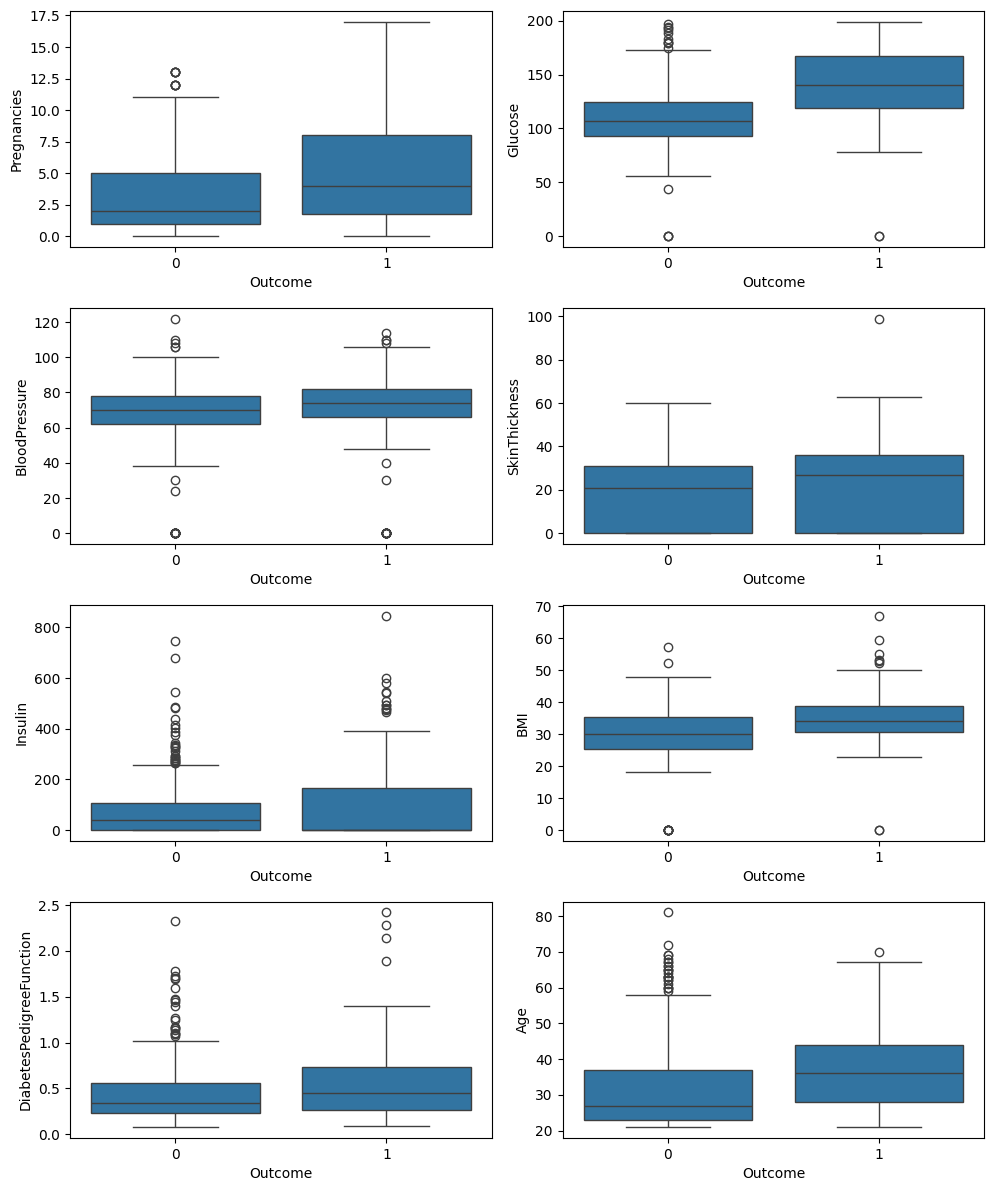

In [8]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
for i, col in enumerate(features):
    sns.boxplot(data=df, x='Outcome', y=col, ax=axes[i//2, i%2])
plt.tight_layout()
plt.show()

## Correlation heatmap

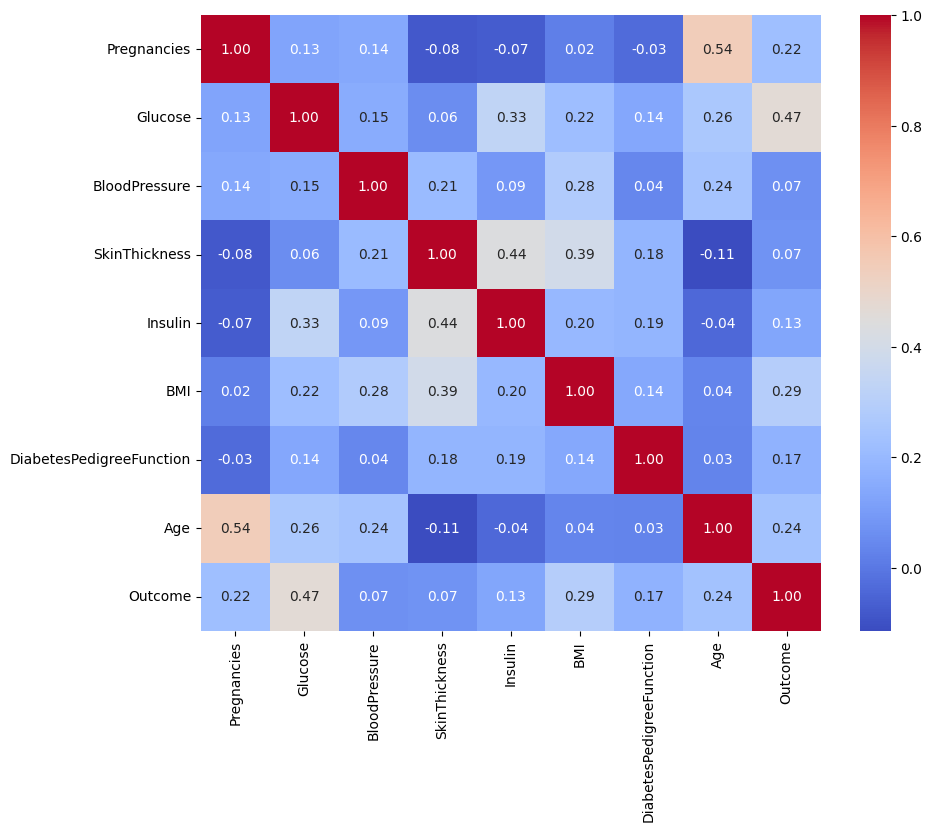

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [10]:
df.groupby('Outcome')[['SkinThickness_missing', 'Insulin_missing']].mean()

KeyError: "Columns not found: 'SkinThickness_missing', 'Insulin_missing'"